<a href="https://colab.research.google.com/github/Adityabhor123/Data_Science_Lab/blob/main/Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Columns:
 Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare'],
      dtype='object')

Cleaned Columns:
 Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare'],
      dtype='object')

First 5 Rows:
    Survived  Pclass                                               Name  \
0         0       3                             Mr. Owen Harris Braund   
1         1       1  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2         1       3                              Miss. Laina Heikkinen   
3         1       1        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4         0       3                            Mr. William Henry Allen   

      Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard     Fare  
0    male  22.0                        1                        0   7.2500  
1  female  38.0                        1                     

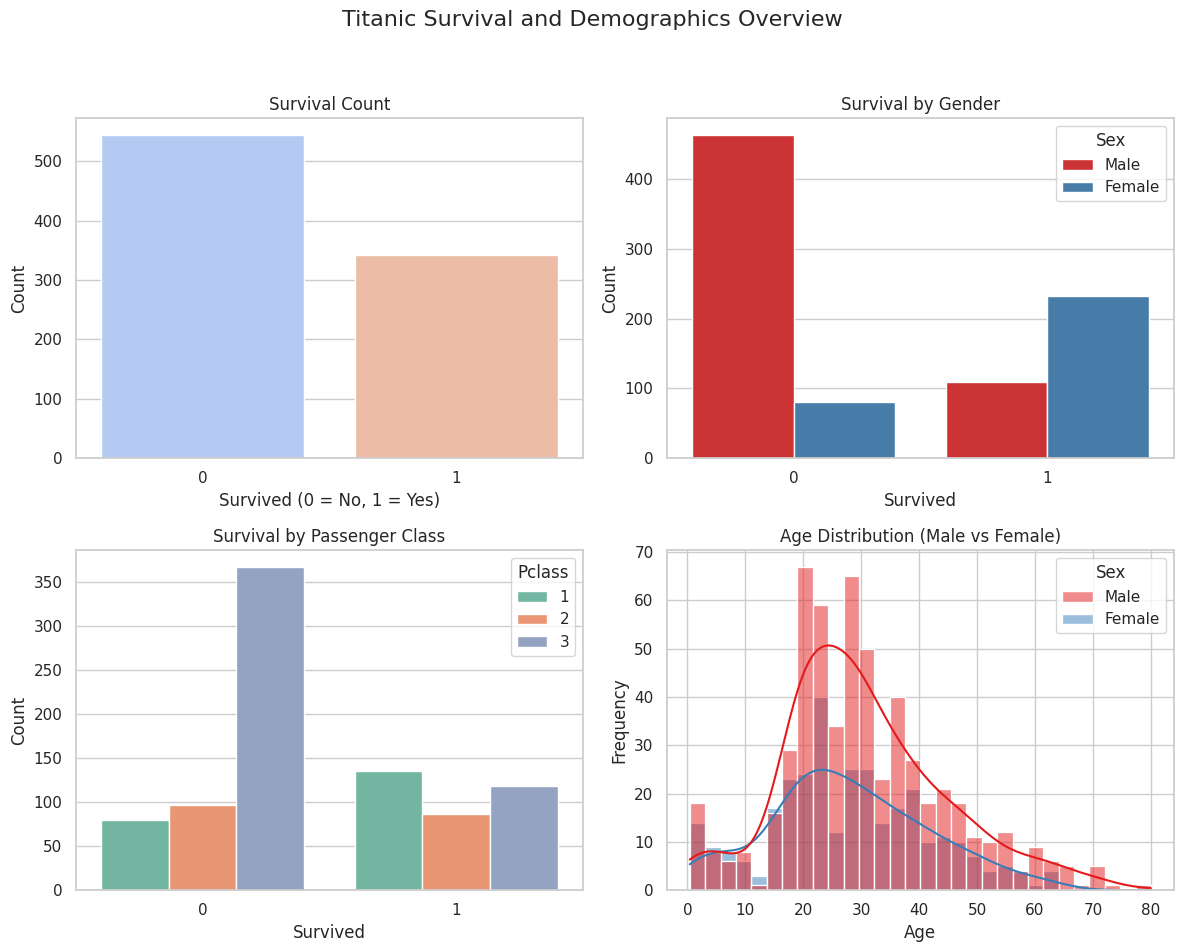

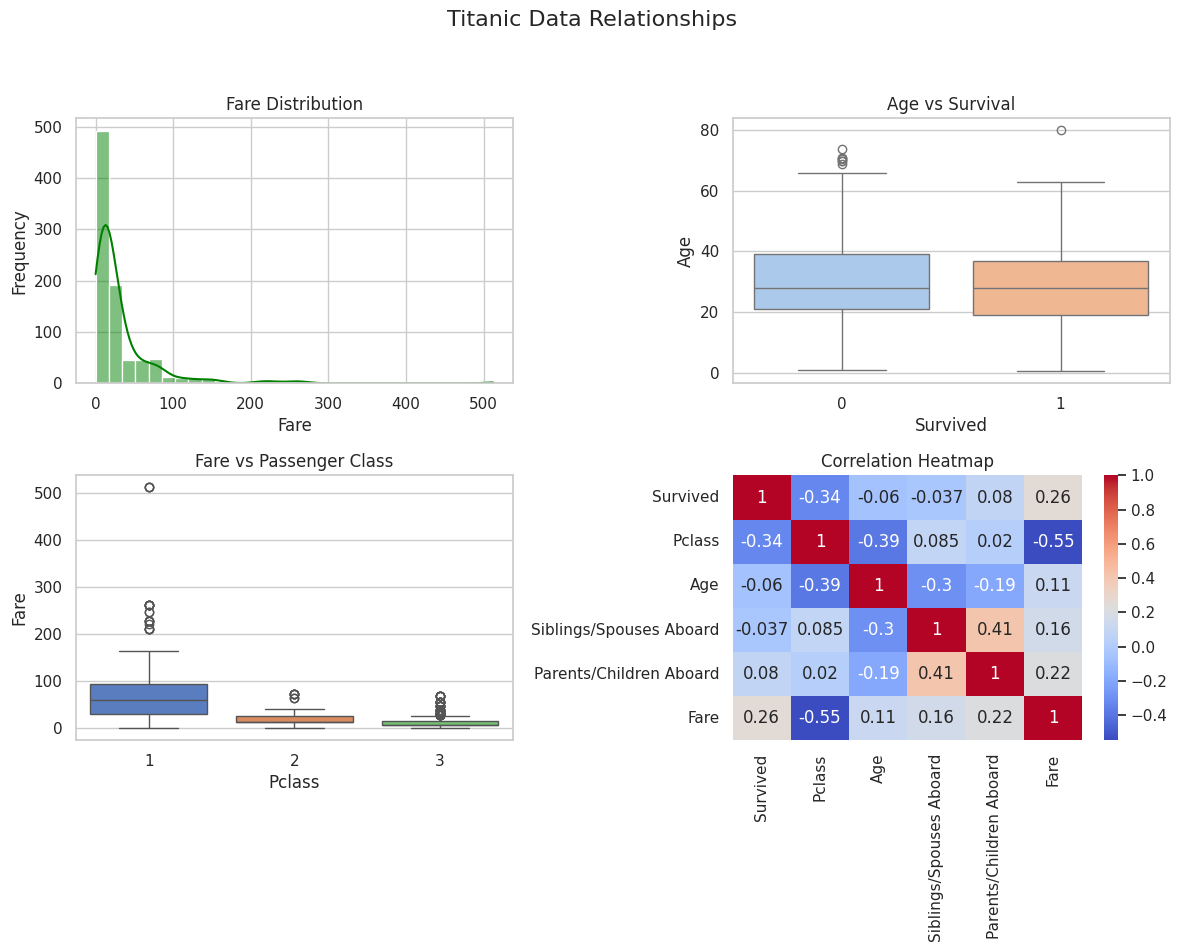

In [15]:
# ================= TITANIC DATA ANALYSIS (DETAILED & ERROR-FREE) ================= #

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

#  2. LOAD DATASET
df = pd.read_csv("titanic.csv")

#  3. CHECK & CLEAN COLUMN NAMES
print("Original Columns:\n", df.columns)

# Remove spaces from column names
df.columns = df.columns.str.strip()

print("\nCleaned Columns:\n", df.columns)

#  4. BASIC DATA INFO
print("\nFirst 5 Rows:\n", df.head())
print("\nDataset Info:\n")
df.info()

print("\nMissing Values:\n", df.isnull().sum())

#  5. HANDLE MISSING VALUES

# Age
if 'Age' in df.columns:
    df['Age'] = df['Age'].fillna(df['Age'].median())

# Embarked
if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin (drop if exists)
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)

print("\nMissing Values After Cleaning:\n", df.isnull().sum())

#  6. DATA TRANSFORMATION

# Convert Sex to descriptive strings for better legend labels
if 'Sex' in df.columns:
    df['Sex'] = df['Sex'].map({'male': 'Male', 'female': 'Female'})

# Convert Embarked to numeric (if 'Embarked' existed, which it doesn't in this dataset)
if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

#  7. SUMMARY STATISTICS
print("\nSummary Statistics:\n", df.describe()) # Note: 'Sex' will no longer be in numeric summary

#  8. DATA VISUALIZATION

# Grouping first 4 plots into a 2x2 grid
fig1, axes1 = plt.subplots(2, 2, figsize=(12, 10))
fig1.suptitle("Titanic Survival and Demographics Overview", fontsize=16)

# Survival Count
if 'Survived' in df.columns:
    sns.countplot(x='Survived', hue='Survived', data=df, palette='coolwarm', ax=axes1[0, 0], legend=False)
    axes1[0, 0].set_title("Survival Count")
    axes1[0, 0].set_xlabel("Survived (0 = No, 1 = Yes)")
    axes1[0, 0].set_ylabel("Count")

# Survival by Gender
if 'Sex' in df.columns and 'Survived' in df.columns:
    sns.countplot(x='Survived', hue='Sex', data=df, palette='Set1', ax=axes1[0, 1])
    axes1[0, 1].set_title("Survival by Gender")
    axes1[0, 1].set_xlabel("Survived")
    axes1[0, 1].set_ylabel("Count")
    # Legend will now automatically show 'Male' and 'Female'

# Survival by Passenger Class
if 'Pclass' in df.columns and 'Survived' in df.columns:
    sns.countplot(x='Survived', hue='Pclass', data=df, palette='Set2', ax=axes1[1, 0])
    axes1[1, 0].set_title("Survival by Passenger Class")
    axes1[1, 0].set_xlabel("Survived")
    axes1[1, 0].set_ylabel("Count")

# Age Distribution
if 'Age' in df.columns and 'Sex' in df.columns:
    sns.histplot(data=df, x='Age', hue='Sex', bins=30, kde=True, palette='Set1', ax=axes1[1, 1])
    axes1[1, 1].set_title("Age Distribution (Male vs Female)")
    axes1[1, 1].set_xlabel("Age")
    axes1[1, 1].set_ylabel("Frequency")
    # Legend will now automatically show 'Male' and 'Female'
    # Removed explicit axes1[1, 1].legend(title='Sex') as sns.histplot handles it with hue

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlapping titles
plt.show()

# Grouping remaining 4 plots into another 2x2 grid
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
fig2.suptitle("Titanic Data Relationships", fontsize=16)

# Fare Distribution
if 'Fare' in df.columns:
    sns.histplot(df['Fare'], bins=30, kde=True, color='green', ax=axes2[0, 0])
    axes2[0, 0].set_title("Fare Distribution")
    axes2[0, 0].set_xlabel("Fare")
    axes2[0, 0].set_ylabel("Frequency")

# Age vs Survival
if 'Age' in df.columns and 'Survived' in df.columns:
    sns.boxplot(x='Survived', y='Age', data=df, palette='pastel', ax=axes2[0, 1], hue='Survived', legend=False)
    axes2[0, 1].set_title("Age vs Survival")

# Fare vs Passenger Class
if 'Fare' in df.columns and 'Pclass' in df.columns:
    sns.boxplot(x='Pclass', y='Fare', data=df, palette='muted', ax=axes2[1, 0], hue='Pclass', legend=False)
    axes2[1, 0].set_title("Fare vs Passenger Class")

# Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes2[1, 1])
sns.set(rc={'figure.figsize':(10,6)})
axes2[1, 1].set_title("Correlation Heatmap")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlapping titles
plt.show()


